#클로드와 함께한 groupby & 특정 조건 과제

In [4]:
import pandas as pd

# sample_data 폴더 내의 CSV 파일 경로 지정
# 해당 데이터는 직접 크롤링 & 데이터 전처리를 통해 수집한 자료입니다.
file_path = '/content/sample_data/scentive_master_db_v10.csv'

#파일을 읽는 순간 데이터프레임으로 변환
df = pd.read_csv(file_path)
print('== 해당 파일의 차원의 형태는 : ', df.shape, '==')

== 해당 파일의 차원의 형태는 :  (2387, 23) ==


In [5]:
print('== 데이터프레임의 열 이름을 나열하면 ==\n', df.columns.tolist)

== 데이터프레임의 열 이름을 나열하면 ==
 <bound method IndexOpsMixin.tolist of Index(['Ingredient', 'CAS_Code', 'Synonyms', 'Scent_Keywords',
       'Human_Description', 'Evaluation_Condition', 'Dilution_Percentage',
       'Note_Classification', 'Potential_Blenders', 'IFRA_Max_Level',
       'IFRA_Max_Pct', 'IFRA_Recommended_Max_Pct', 'Tenacity_Hours',
       'Flash_Point_Celsius', 'Color', 'Source_Type', 'Molecular_Weight',
       'Molecular_Formula', 'XLogP', 'Volatility_Estimate',
       'Ethanol_Solubility', 'Usage_Rate_Min_Pct', 'Usage_Rate_Max_Pct'],
      dtype='object')>


In [23]:
print('== 상위 2개의 데이터만 뽑아본다면 ==\n',df.head(2))

== 상위 2개의 데이터만 뽑아본다면 ==
                          Ingredient    CAS_Code  \
0                 angelica seed oil   8015-64-3   
1  isobutyl (E,E)-2,4-decadienamide  18836-52-7   

                                            Synonyms  \
0  angelica archangelica seed oil; angelica seed ...   
1  N-isobutyl (E,E)-2,4-decadienamide; (2E,4E)-N-...   

                                      Scent_Keywords Human_Description  \
0  strong fresh terpenic peppery earthy spicy ani...   상쾌하고 테르페닉한 머스크향   
1                                       spicy herbal         허벌한 스파이시향   

               Evaluation_Condition  Dilution_Percentage Note_Classification  \
0  at 10.00 % in dipropylene glycol                 10.0                Base   
1   at 1.00 % in dipropylene glycol                  1.0          Top,Middle   

                                  Potential_Blenders  \
0  angelica leaf oil; citrus carbaldehyde; dodeca...   
1  menth-1-en-9-al; agrumen nitrile; heptanone; o...   

                   

In [9]:
print('== 데이터프레임의 구조와 요약 정보는 다음과 같다 == \n')
df.info()

== 데이터프레임의 구조와 요약 정보는 다음과 같다 == 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2387 entries, 0 to 2386
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Ingredient                2387 non-null   object 
 1   CAS_Code                  2387 non-null   object 
 2   Synonyms                  2387 non-null   object 
 3   Scent_Keywords            2387 non-null   object 
 4   Human_Description         2387 non-null   object 
 5   Evaluation_Condition      2387 non-null   object 
 6   Dilution_Percentage       2387 non-null   float64
 7   Note_Classification       2387 non-null   object 
 8   Potential_Blenders        2387 non-null   object 
 9   IFRA_Max_Level            2387 non-null   object 
 10  IFRA_Max_Pct              2307 non-null   float64
 11  IFRA_Recommended_Max_Pct  2307 non-null   float64
 12  Tenacity_Hours            1268 non-null   float64
 13  Flash_Point_Celsius       238

##groupby 사용해보기

In [18]:
#groupby 사용해보기
#index 0번 - ingredient
#index 15번 - Source_Type별 재료 수 집계
result1 = df.groupby('Source_Type')['Ingredient'].count()
print("2387개의 원료 데이터를 source_type별로 개수를 세면 다음과 같다:\n")
print(result1)

2387개의 원료 데이터를 source_type별로 개수를 세면 다음과 같다:

Source_Type
natural      1539
synthetic     848
Name: Ingredient, dtype: int64


In [16]:
#groupby 사용해보기
#index 13번 - Tenacity_Hours
#index 7번 - Note_Classification별 평균 Tenacity (지속시간)
result2 = df.groupby('Note_Classification')['Tenacity_Hours'].mean()
print("각 향료의 분류별로 평균 지속시간은 아래와 같다.\n")
print(result2.sort_values(ascending=False))

각 향료의 분류별로 평균 지속시간은 아래와 같다.

Note_Classification
Base               360.868778
Middle,Base        188.372093
Top,Base           174.460432
Top,Middle,Base    156.340909
Middle              90.993289
Top,Middle          65.036735
Top                  8.682464
Name: Tenacity_Hours, dtype: float64


In [22]:
#groupby 사용해보기
#index 22번 - Usage_Rate_Max_Pct
#index 19번 - Volatility_Estimate
#index 15번 - Source_Type
#Source_Type + Volatility_Estimate 복합 groupby → 평균 사용량
result3 = df.groupby(['Source_Type', 'Volatility_Estimate'])['Usage_Rate_Max_Pct'].mean().reset_index()
result3 = result3.rename(columns={'Usage_Rate_Max_Pct': 'Usage_Rate_Max_Pct_Mean'})
print('source_type별 휘발되는 정도로 구분하고(high,low,medium) \n 각 휘발정도에 따라 조향시 권장되는 최대 사용 비율의 평균은 아래와 같다:\n')
print(result3)

source_type별 휘발되는 정도로 구분하고(high,low,medium) 
 각 휘발정도에 따라 조향시 권장되는 최대 사용 비율의 평균은 아래와 같다:

  Source_Type Volatility_Estimate  Usage_Rate_Max_Pct_Mean
0     natural                high                 1.821782
1     natural                 low                 4.393939
2     natural              medium                 2.943983
3   synthetic                high                 2.558824
4   synthetic                 low                 5.481928
5   synthetic              medium                 3.090047


## 조건 필터링해보기

In [24]:
# 천연 재료(natural)만 추출
natural_df = df[df['Source_Type'] == 'natural']
print(f"천연 재료 수: {len(natural_df)}")

천연 재료 수: 1539


In [31]:
# 여러 조건 조합 — 합성(synthetic) + 사용량 최대 5% 이상 + 인화점 100°C 이상
safe_synthetic = df[
    (df['Source_Type'] == 'synthetic') &
    (df['Usage_Rate_Max_Pct'] >= 5.0) &
    (df['Flash_Point_Celsius'] >= 100)
]
print(f"합성재료이며, 사용량 최대 5% 이상이고 인화점 100°C 이상인 원료는 총 {len(safe_synthetic)}개 이며,\n목록은 다음과 같다:\n")
print(safe_synthetic[['Ingredient', 'Usage_Rate_Max_Pct', 'Flash_Point_Celsius']])


합성재료이며, 사용량 최대 5% 이상이고 인화점 100°C 이상인 원료는 총 89개 이며,
목록은 다음과 같다:

                                            Ingredient  Usage_Rate_Max_Pct  \
3                   hydroxycitronellal dimethyl acetal                 8.0   
8                                           musk ether                 8.0   
33                             acetyl tributyl citrate                 8.0   
35                                      sandal hexanol                 8.0   
53    benzaldehyde / methyl anthranilate schiff's base                 8.0   
...                                                ...                 ...   
2319                            citronellyl ethoxalate                 8.0   
2335                 isomethyl tetrahydroionyl acetate                 8.0   
2352                                   boronia butenal                 8.0   
2365                                   sandal pentenol                 8.0   
2373                           rhodinyl phenyl acetate                 8.0   


#클로드와 함께하는 데이터 시각화

In [33]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kursatdinc/airline-passangers")

print("파일 목록:", path)

Using Colab cache for faster access to the 'airline-passangers' dataset.
파일 목록: /kaggle/input/airline-passangers


In [35]:
import matplotlib.pyplot as plt
import os

df = pd.read_csv(os.path.join(path, os.listdir(path)[0]))
print(df.head())

     month  total_passengers
0  1949-01               112
1  1949-02               118
2  1949-03               132
3  1949-04               129
4  1949-05               121


In [36]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   month             144 non-null    object
 1   total_passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB
None


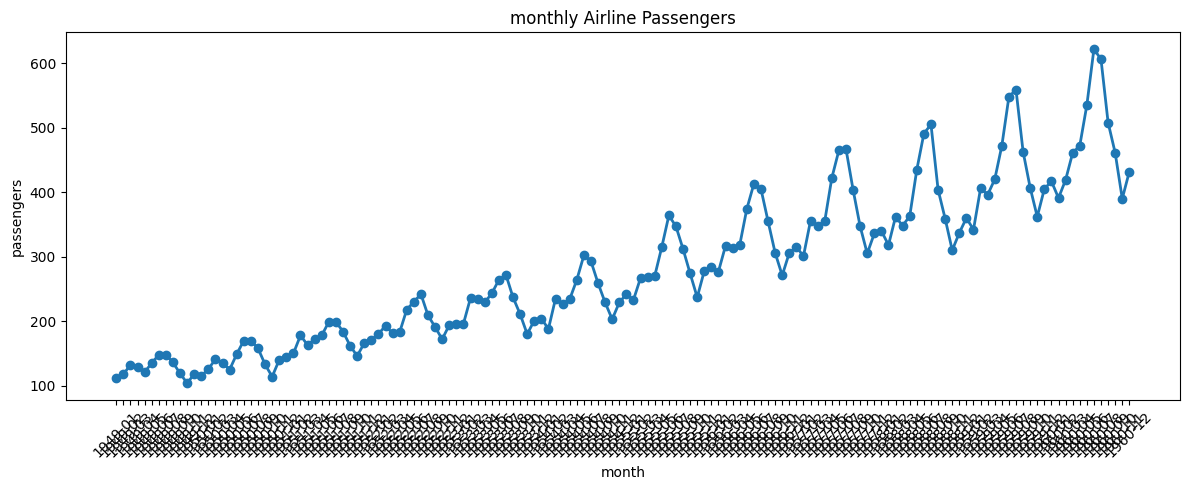

In [41]:
#시각화 1 — 시계열 추이 (선 그래프)

plt.figure(figsize=(12, 5))
plt.plot(df['month'], df['total_passengers'], marker='o', linewidth=2)
plt.title('monthly Airline Passengers')
plt.xlabel('month')
plt.ylabel('passengers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

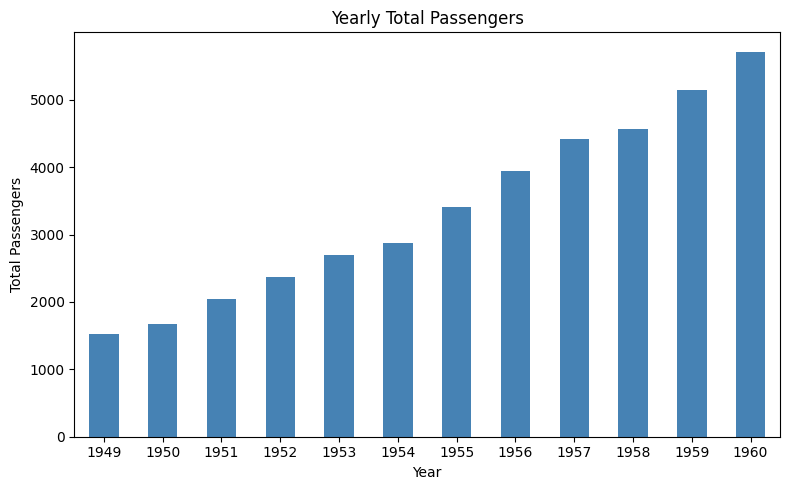

In [42]:
#시각화 2 — 연도별 승객 수 (막대 그래프)

df['Year'] = pd.to_datetime(df['month']).dt.year

yearly = df.groupby('Year')['total_passengers'].sum()

plt.figure(figsize=(8, 5))
yearly.plot(kind='bar', color='steelblue')
plt.title('Yearly Total Passengers')
plt.xlabel('Year')
plt.ylabel('Total Passengers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

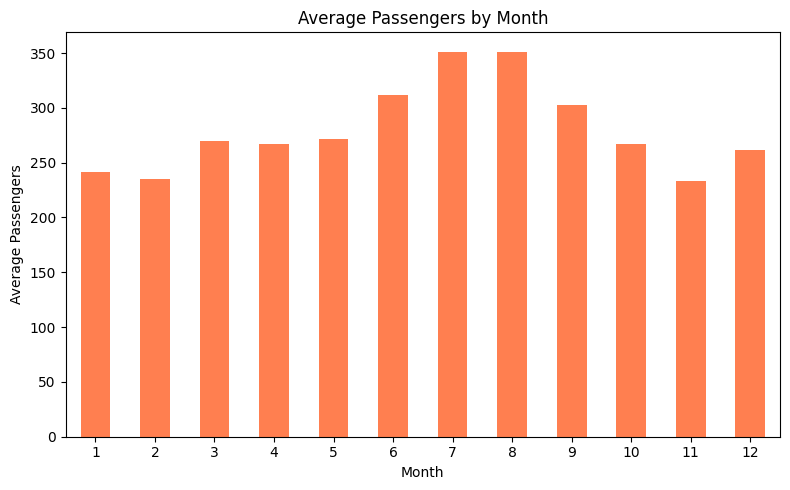

In [43]:
#시각화 3 — 월별 평균 (계절성 확인)

df['MonthNum'] = pd.to_datetime(df['month']).dt.month

monthly_avg = df.groupby('MonthNum')['total_passengers'].mean()

plt.figure(figsize=(8, 5))
monthly_avg.plot(kind='bar', color='coral')
plt.title('Average Passengers by Month')
plt.xlabel('Month')
plt.ylabel('Average Passengers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()